In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot') 
pd.set_option('display.max_colwidth', None)

    
df = pd.read_csv("../data/clickbait_title_classification.csv")
df.head(10)





,title,clickbait
0,""".asia"" domain applications near 300,000 on opening of registration",0
1,"""1 Indian + 1 Indian = Unrelatable"": Television's Race Equations",1
2,"""7th Heaven"" television series comes to an end",0
3,"""Arm Glow"" Is Your New Life Goal, Thanks To Lupita Nyong'o",1
4,"""Beans Memes"" Is The Only Twitter Account That Actually Matters",1
5,"""Bigoted woman"": controversial Gordon Brown remarks caught on air",0
6,"""Black Mirror"" Creator On David Cameron's PigGate: ""I Didn't Try To Predict This""",1
7,"""Black box"" found near crash site of Ethiopian Airlines flight",0
8,"""Black-ish"" Will Tackle The N-Word In Season Premiere",1
9,"""Brooklyn"" Star Saoirse Ronan Actually Wants To Move To Brooklyn",1


In [3]:
df.shape


(32000, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   title      32000 non-null  str  
 1   clickbait  32000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 500.1 KB


In [5]:
df.isna().sum()

title        0
clickbait    0
dtype: int64

In [6]:
df.dtypes

title          str
clickbait    int64
dtype: object

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['clickbait'].value_counts()

clickbait
0    16001
1    15999
Name: count, dtype: int64

In [9]:
df[df['clickbait'] == 0]['title'].head(20)

0                                    ".asia" domain applications near 300,000 on opening of registration
2                                                         "7th Heaven" television series comes to an end
5                                      "Bigoted woman": controversial Gordon Brown remarks caught on air
7                                         "Black box" found near crash site of Ethiopian Airlines flight
10                                       "Camp Casey" moves to safer land, as Mother's protest continues
14                                                     "Children of Men" wins Scripter Award for writing
15                                       "Civil defence" thwarts Israeli air strike on Gaza refugee camp
17    "Creationism and intelligent design have no place in the UK science curriculum" says UK Government
24                                                  "Donkey" bloggers facing jail sentence in Azerbaijan
26                                          "Dr Dino" g

In [10]:
df[df['clickbait'] == 1]['title'].head(20)

1                      "1 Indian + 1 Indian = Unrelatable": Television's Race Equations
3                            "Arm Glow" Is Your New Life Goal, Thanks To Lupita Nyong'o
4                       "Beans Memes" Is The Only Twitter Account That Actually Matters
6     "Black Mirror" Creator On David Cameron's PigGate: "I Didn't Try To Predict This"
8                                 "Black-ish" Will Tackle The N-Word In Season Premiere
9                      "Brooklyn" Star Saoirse Ronan Actually Wants To Move To Brooklyn
11                                   "Carol" Offers A Rare Ending For A Lesbian Romance
12                                          "Cats" The Musical Is Returning To Broadway
13                    "Celebrities In Ramen" Is The Instagram You Never Knew You Needed
16                          "Clearest Blue" By Chvrches Is One Of The Year's Best Songs
18                                     "Creed" Is "Rocky" Without The Racial Insecurity
19                              

In [11]:
df['clickbait'].value_counts()

clickbait
0    16001
1    15999
Name: count, dtype: int64

In [12]:
df['title'].str.len().describe()

count    32000.000000
mean        53.804063
std         14.774600
min          6.000000
25%         44.000000
50%         52.000000
75%         63.000000
max        135.000000
Name: title, dtype: float64

In [13]:
df.groupby('clickbait')['title'].apply(lambda x: x.str.len().describe())

clickbait       
0          count    16001.000000
           mean        51.857071
           std         14.358112
           min         11.000000
           25%         42.000000
           50%         49.000000
           75%         60.000000
           max        135.000000
1          count    15999.000000
           mean        55.751297
           std         14.928293
           min          6.000000
           25%         46.000000
           50%         56.000000
           75%         65.000000
           max        125.000000
Name: title, dtype: float64

<Axes: title={'center': 'Clickbait Counts'}, xlabel='clickbait'>

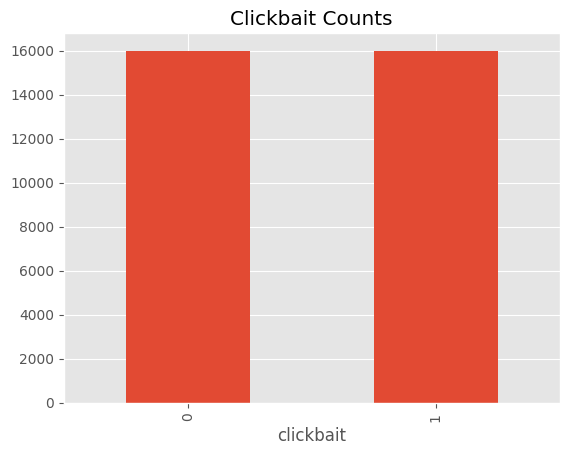

In [14]:
df['clickbait'].value_counts() \
    .head(100) \
    .plot(kind = 'bar', title= 'Clickbait Counts')
    

In [15]:
df['title_length'] = df['title'].str.len()
df.head()

,title,clickbait,title_length
0,""".asia"" domain applications near 300,000 on opening of registration",0,67
1,"""1 Indian + 1 Indian = Unrelatable"": Television's Race Equations",1,64
2,"""7th Heaven"" television series comes to an end",0,46
3,"""Arm Glow"" Is Your New Life Goal, Thanks To Lupita Nyong'o",1,58
4,"""Beans Memes"" Is The Only Twitter Account That Actually Matters",1,63


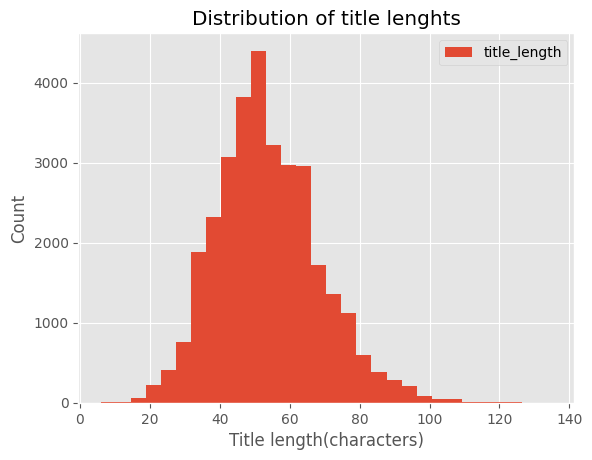

In [16]:
df['title_length'].plot(kind='hist',bins = 30)
plt.title("Distribution of title lenghts")
plt.xlabel("Title length(characters)")
plt.ylabel('Count')
plt.legend()
plt.show()



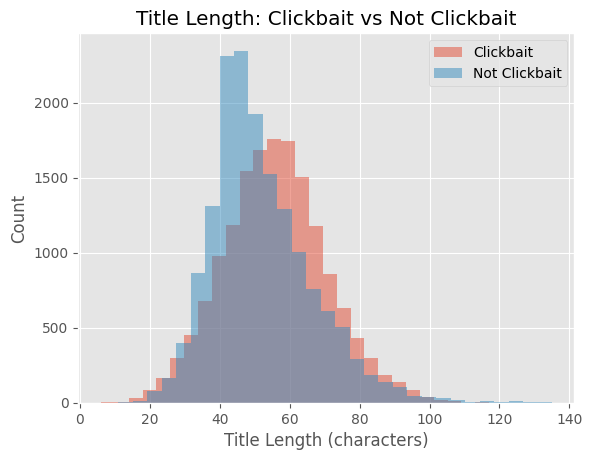

In [17]:
clickbait_lengths = df[df['clickbait'] == 1]['title_length']
nonclickbait_lengths = df[df['clickbait'] == 0]['title_length']
clickbait_lengths.plot(kind='hist', bins=30, alpha=0.5, label='Clickbait')

nonclickbait_lengths.plot(kind='hist', bins=30, alpha=0.5, label='Not Clickbait')

plt.title('Title Length: Clickbait vs Not Clickbait')
plt.xlabel('Title Length (characters)')
plt.ylabel('Count')
plt.legend()
plt.show()  

{'between', 'until', 'of', 'being', 'but', 'themselves', "mightn't", 'me', 'up', "wouldn't", 'just', 'he', 'in', 'did', "i've", 'hasn', 'i', 'own', "shouldn't", 'shan', 'very', 'ain', 'again', 'wouldn', "she'll", 'only', 'other', 'ourselves', 'few', "shan't", 'she', 'most', "he'd", "that'll", "aren't", 'which', 'hadn', 'against', 'into', "didn't", "you'd", 'off', 'nor', 'what', 'or', "they're", 'were', 'am', 's', 'it', 'itself', 'theirs', "needn't", 'we', 'haven', 'that', "he'll", "couldn't", "it's", "they'll", 'wasn', "weren't", 'before', 'as', "isn't", 'their', 'been', 'y', 'to', 're', "doesn't", "you've", 'with', 'here', 'too', 'below', 'these', 'on', "don't", 'once', "we'd", 'its', "they've", 'a', 'if', 'whom', "hadn't", "you're", "we'll", "he's", 'him', 'the', 'this', 'and', 'them', "should've", 'mustn', "she'd", 'each', 'from', 'couldn', 'those', "we've", 'such', 'needn', 'by', 'weren', 'yours', 'will', 'any', 'yourselves', 'our', 'about', 'why', 'while', 'his', 'who', 'under', '

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jscutari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Axes: >

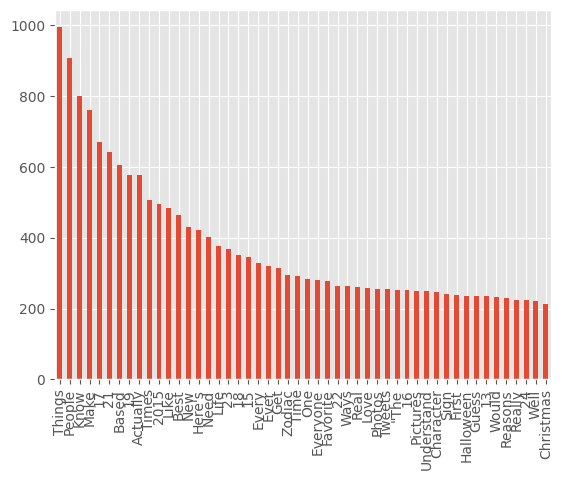

In [18]:
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

english_stopwords = set(stopwords.words('english'))
print(english_stopwords)



clickbait_words = ' '.join(df[df['clickbait'] == 1]['title']).split() 

filtered_words = [word for word in clickbait_words if word.lower() not in english_stopwords]

clickbait_counts = Counter(filtered_words)

pd.Series(dict(clickbait_counts.most_common(50))) \
    .plot(kind="bar")


